In [38]:
# Data manipulation and analysis
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

# Astropy modules
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from astropy.convolution import Gaussian1DKernel, convolve_fft
from astropy.coordinates import SkyCoord

# Matplotlib for plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Scipy and related modules
import scipy.sparse as sp
from scipy.optimize import curve_fit

# Spectral cube handling
from spectral_cube import SpectralCube as sc

# Progress bar
from tqdm.notebook import tqdm, trange

# Additional libraries
from kneed import KneeLocator
from photutils.aperture import SkyEllipticalAperture
from regions import EllipseSkyRegion

# Multithreading
import os
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict

# Multithreading
from joblib import Parallel, delayed

# Galaxy rotation curve
import sys
sys.path.append("../Galaxy Rotation Model/")

from rotation_model_numpy import calc_v_dev

# Suppress warnings from spectral_cube
import warnings
from spectral_cube.utils import PossiblySlowWarning
warnings.filterwarnings("ignore", category=PossiblySlowWarning)

# Set global options for numpy and matplotlib
np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})
delta_min = 1e-12

%matplotlib widget

In [2]:
# Define the source and target cube patterns

crafts_file = "./test.fits"
hi4pi_file = "./hi4pi_test_reprojected.fits"
output_pattern = "./Figures/moment{m}_test.fits"
catalog_file = "./Catalogs/catalog_test.csv"

moments = [0, 1, 2]

output_file = []
for m in moments:
    output_file.append(output_pattern.format(m=m))

In [3]:
# CRAFTS cube

cube = sc.read(crafts_file).with_spectral_unit(u.km / u.s)
cube = cube[::-1, :, :]  # flip the velocity axis of CRAFTS cube
data = cube.unmasked_data[:, :, :].value
hdr = cube.header
wcs = WCS(hdr)
pixel_to_deg = hdr["CDELT2"]

# data mask
# data[:,:,0:201] = np.nan

MEDIAN = np.nanmedian(data)
STD = np.nanstd(data)
print("Mean:", MEDIAN)
print("Std:", STD, "\n")

data = np.nan_to_num(data)
velocities = cube.spectral_axis.value
delta_v = np.abs(velocities[1] - velocities[0])  # velocity resolution in km/s
print("CRAFTS cube\n", cube)
print("delta_v =", delta_v, "km/s\n")

# Uncomment the following lines if you want to average every two slices

# stack = data.shape[0]
# for i in range(0, stack, 2):
#     if i // 2 < stack // 2:
#         data[i // 2] = (data[i] + data[i + 1]) / 2
#
# data = data[: stack // 2]

# HI4PI cube

hi4pi_cube = sc.read(hi4pi_file).with_spectral_unit(u.km / u.s)
hi4pi_cube = hi4pi_cube.spectral_slab(velocities[0] * u.km / u.s, velocities[-1] * u.km / u.s)
hidpi_data = hi4pi_cube.unmasked_data[:, :, :].value
hi4pi_velocities = hi4pi_cube.spectral_axis.value
hi4pi_delta_v = np.abs(hi4pi_velocities[1] - hi4pi_velocities[0])
print("HI4PI cube\n", hi4pi_cube)
print("hi4pi_delta_v =", hi4pi_delta_v, "km/s")

Mean: 0.0090981275
Std: 0.1310845 

CRAFTS cube
 SpectralCube with shape=(995, 221, 481):
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    221  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -7.487500 deg
 n_s:    995  type_s: VRAD      unit_s: km / s  range:       99.966 km / s:     300.042 km / s
delta_v = 0.20128359473301316 km/s

HI4PI cube
 SpectralCube with shape=(995, 221, 481) and unit=K:
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    221  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -7.487500 deg
 n_s:    995  type_s: VRAD      unit_s: km / s  range:       99.966 km / s:     300.042 km / s
hi4pi_delta_v = 0.20128359473295632 km/s


computing ratios:   0%|          | 0/21 [00:00<?, ?it/s]

Best value of x = 2.0
N(>xσ) / N(total) = 0.0263


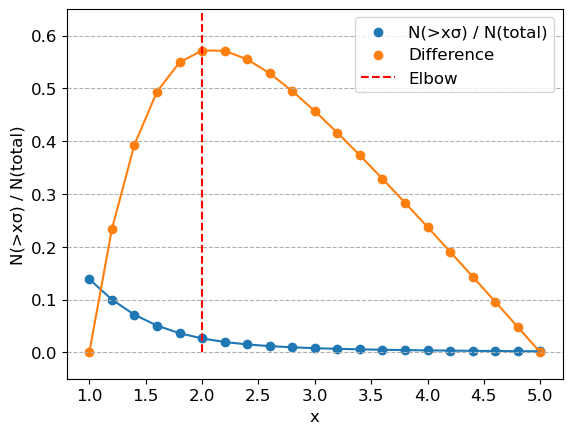

In [4]:
# sigma clipping data to select value v > xσ

# use knee/elbow value to find the best x value
x_ = np.arange(1, 5.2, 0.2)

def ratio_for_x(x_val):
    upper_bound = MEDIAN + STD * x_val
    return np.count_nonzero(data > upper_bound) / np.count_nonzero(data)

with ThreadPoolExecutor(max_workers=(os.cpu_count() or 1)) as executor:
    y_ = list(tqdm(executor.map(ratio_for_x, x_), total=len(x_), desc="computing ratios"))

kneedle = KneeLocator(x_, y_, S=1.0, curve="convex", direction="decreasing")

print("Best value of x =", round(kneedle.elbow, 4))
print("N(>xσ) / N(total) =", round(kneedle.elbow_y, 4))

# plot the results as in kneedle.plot_knee()
fig, ax = plt.subplots()
ax.scatter(x_, y_, label="N(>xσ) / N(total)")
ax.scatter(x_, kneedle.y_difference, label="Difference")
ax.plot(x_, y_)
ax.plot(x_, kneedle.y_difference)
ax.set_ylim(-0.05, 0.65)
ax.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red", label="Elbow")
ax.set_xlabel("x")
ax.set_ylabel("N(>xσ) / N(total)")
ax.grid(axis="y", ls="--")
ax.legend()
plt.show()

In [5]:
upper_bound = MEDIAN + STD * kneedle.elbow
snr_mask = data > upper_bound

In [6]:
ny, nx = data.shape[-2], data.shape[-1]

def pix_to_galactic_l_b(celestial_wcs, xpix, ypix):
    lonlat = celestial_wcs.all_pix2world(xpix, ypix, 0)
    ctypes = celestial_wcs.wcs.ctype
    c0 = ctypes[0].upper()
    if "RA" in c0 or "DEC" in c0:
        sc = SkyCoord(ra=lonlat[0]*u.deg, dec=lonlat[1]*u.deg, frame='fk5')
        gal = sc.galactic
        return gal.l.deg, gal.b.deg
    else:
        return lonlat[0], lonlat[1]

pos_mask = np.zeros_like(data, dtype=bool)
neg_mask = np.zeros_like(data, dtype=bool)
# Create meshgrids for l and b
x_grid, y_grid = np.meshgrid(np.arange(nx), np.arange(ny))  # x_grid: (ny, nx), y_grid: (ny, nx)
# Vectorized computation of Galactic coordinates
l_deg, b_deg = pix_to_galactic_l_b(wcs.celestial, x_grid, y_grid)

# Vectorized call to calc_v_dev
v_max, v_min = calc_v_dev(l_deg, b_deg, model="poly", v_dev=0)

# print center value of v_max, v_min
print(v_max[ny//2, nx//2])
print(v_min[ny//2, nx//2])

# Create masks: broadcast vel_axis to (nv, ny, nx)
v_pos_mask = velocities[:, None, None] > v_max[None, :, :]
v_neg_mask = velocities[:, None, None] < v_min[None, :, :]

89.50509880942818
-0.0


In [7]:
# index is a 2D array, where each row is [v, y, x] coordinate for a point with value v > sσ
# this will be used for clustering
# index = np.argwhere(snr_mask & pos_mask)
index = np.argwhere(snr_mask)

# DBSCAN

In [8]:
# Set the parameters for DBSCAN: eps, minPts

eps = np.sqrt(3)
minPts = 12

In [9]:
# DBSCAN clustering

db = DBSCAN(eps=eps, min_samples=minPts, n_jobs=-1).fit(index)  # DBSCAN clustering
# db.labels_ is an array of the same length as index, where each element is the cluster label for that point.
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters)
print("Estimated number of noise points: %d" % n_noise)

Estimated number of clusters: 3397
Estimated number of noise points: 1586339


# 计算 Moment 0, 1, 2

In [10]:
# Calculate moment 0 using pure Python (faster for smaller clusters)
def moment_0_py(data, vyx):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]  # velocity [v]
    coords = vyx[:, 1:]  # coordinates [y, x]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # unique_coords is a 2D array of unique [y, x] coordinates
    # indices is an array of the same length as coords, where each element is the index of the unique coordinate
    # This means that for each coordinate in coords, we can find several velocities in velo that correspond to it.

    # Calculate moment 0 of the velocity axis
    # for each unique pair of the coordinates
    def calc_moment_0(unique_coords, indices, velo, data):
        moment_0 = np.zeros(len(unique_coords))
        for i in range(len(unique_coords)):  # for each unique coordinate
            # Calculate the moment 0 for this coordinate
            # M0 = \int I_v dv = \sum I_v * delta_v
            m0 = 0
            coo = unique_coords[i]
            for v in velo[
                indices == i
            ]:  # sum over all velocities that correspond to this coordinate
                m0 += data[v, coo[0], coo[1]] * delta_v  # moment 0
            moment_0[i] = m0
        return moment_0

    moment_0 = calc_moment_0(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_0_coo = sp.coo_array(
        (moment_0, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_0_coo


# Calculate moment 0 using pure Spectral-Cube (faster for larger clusters)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170
def moment_0_sc(data, vyx):
    # create a cube which only contains the values of points in the cluster (labels == cluster_id)
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # mark all points in the cluster (labels == cluster_id) as True
    )
    cluster_data = (
        bool_array * data
    )  # multiply the data with the boolean array to get only the values of points in the cluster
    bool_cube = sc(cluster_data, wcs=wcs).with_spectral_unit(u.km / u.s)
    # Calculate moment 0 of the velocity axis
    moment_0 = bool_cube.moment(order=0).value
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_0_coo = sp.coo_array(moment_0)
    return moment_0_coo


def moment_0_func(data, index, labels, n_clusters):
    """Optimized version: Pre-grouping + chunksize"""

    # Step 1: Pre-extract indices for each cluster (single scan of labels)
    cluster_indices = defaultdict(list)
    for i, label in enumerate(labels):
        if label >= 0:  # clusters with label = -1 are noise
            cluster_indices[label].append(i)

    # Convert to numpy arrays and slice (avoid boolean indexing in each task)
    cluster_vyx = {}
    for cid, idx_list in cluster_indices.items():
        cluster_vyx[cid] = index[np.array(idx_list, dtype=np.int64)]

    def compute_moment_0_for_cluster(cluster_id):
        vyx = cluster_vyx.get(cluster_id, np.empty((0, 3), dtype=index.dtype))
        if len(vyx) == 0:
            # Return an empty sparse matrix
            return sp.coo_array((data.shape[1], data.shape[2]))
        size = len(vyx)
        if size < 100000:
            return moment_0_py(data, vyx)
        else:
            return moment_0_sc(data, vyx)

    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        # Key: chunksize=256 to reduce scheduling overhead
        mapped = executor.map(compute_moment_0_for_cluster, range(n_clusters), chunksize=256)
        moment_0_results = list(
            tqdm(mapped, total=n_clusters, desc="computing moment_0",
                 mininterval=0.5, miniters=100)
        )

    moment_0_cube = np.hstack(moment_0_results)
    return moment_0_cube

In [11]:
moment_0_cube = moment_0_func(data, index, labels, n_clusters)

computing moment_0:   0%|          | 0/3397 [00:00<?, ?it/s]

In [12]:
# Calculate moment 1 using pure Python (faster for smaller clusters)
def moment_1_py(data, vyx):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]  # velocity [v]
    coords = vyx[:, 1:]  # coordinates [y, x]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # unique_coords is a 2D array of unique [y, x] coordinates
    # indices is an array of the same length as coords, where each element is the index of the unique coordinate
    # This means that for each coordinate in coords, we can find several velocities in velo that correspond to it.

    # Calculate moment 1 of the velocity axis
    # for each unique pair of the coordinates
    def calc_moment_1(unique_coords, indices, velo, data):
        moment_1 = np.zeros(len(unique_coords))
        for i in range(len(unique_coords)):  # for each unique coordinate
            # Calculate the moment 1 for this coordinate
            # M1 = \int v I_v dv / M0 = \sum I_v * v / \sum I_v
            m0 = 0
            m1 = 0
            coo = unique_coords[i]
            for v in velo[
                indices == i
            ]:  # sum over all velocities that correspond to this coordinate
                m0 += data[v, coo[0], coo[1]]
                vel = velocities[v]
                m1 += data[v, coo[0], coo[1]] * vel  # moment 1
            moment_1[i] = m1 / m0
        return moment_1

    moment_1 = calc_moment_1(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_1_coo = sp.coo_array(
        (moment_1, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_1_coo


# Calculate moment 0 using pure Spectral-Cube (faster for larger clusters)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170
def moment_1_sc(data, vyx):
    # create a cube which only contains the values of points in the cluster (labels == cluster_id)
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # mark all points in the cluster (labels == cluster_id) as True
    )
    cluster_data = (
        bool_array * data
    )  # multiply the data with the boolean array to get only the values of points in the cluster
    bool_cube = sc(cluster_data, wcs=wcs).with_spectral_unit(u.km / u.s)
    # Calculate moment 1 of the velocity axis
    moment_1 = bool_cube.moment(order=1).value
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_1_coo = sp.coo_array(moment_1)
    return moment_1_coo


def moment_1_func(data, index, labels, n_clusters):
    """Optimized version: Pre-grouping + chunksize"""

    # Step 1: Pre-extract indices for each cluster (single scan of labels)
    cluster_indices = defaultdict(list)
    for i, label in enumerate(labels):
        if label >= 0:  # clusters with label = -1 are noise
            cluster_indices[label].append(i)

    # Convert to numpy arrays and slice (avoid boolean indexing in each task)
    cluster_vyx = {}
    for cid, idx_list in cluster_indices.items():
        cluster_vyx[cid] = index[np.array(idx_list, dtype=np.int64)]

    def compute_moment_1_for_cluster(cluster_id):
        vyx = cluster_vyx.get(cluster_id, np.empty((0, 3), dtype=index.dtype))
        if len(vyx) == 0:
            # Return an empty sparse matrix
            return sp.coo_array((data.shape[1], data.shape[2]))
        size = len(vyx)
        if size < 100000:
            return moment_0_py(data, vyx)
        else:
            return moment_0_sc(data, vyx)

    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        # Key: chunksize=256 to reduce scheduling overhead
        mapped = executor.map(compute_moment_1_for_cluster, range(n_clusters), chunksize=256)
        moment_1_results = list(
            tqdm(mapped, total=n_clusters, desc="computing moment_1",
                 mininterval=0.5, miniters=100)
        )

    moment_1_cube = np.hstack(moment_1_results)
    return moment_1_cube

In [13]:
moment_1_cube = moment_1_func(data, index, labels, n_clusters)

computing moment_1:   0%|          | 0/3397 [00:00<?, ?it/s]

In [14]:
# Calculate moment 2 (FWHM) using pure Python (faster for smaller clusters)
def moment_2_py(data, vyx):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]  # velocity [v]
    coords = vyx[:, 1:]  # coordinates [y, x]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # unique_coords is a 2D array of unique [y, x] coordinates
    # indices is an array of the same length as coords, where each element is the index of the unique coordinate
    # This means that for each coordinate in coords, we can find several velocities in velo that correspond to it.

    # Calculate moment 2 of the velocity axis
    # for each unique pair of the coordinates
    def calc_moment_2(unique_coords, indices, velo, data):
        moment_2 = np.zeros(len(unique_coords))
        for i in range(len(unique_coords)):  # for each unique coordinate
            # Calculate the moment 1 for this coordinate
            # M2 = \int I_v (v - M1)^2 dv / M0 = \sum I_v * (v - M1)^2 / \sum I_v
            m0 = 0
            m1 = 0
            m2 = 0
            coo = unique_coords[i]
            # Calculate moment 0 and moment 1 for this coordinate
            for v in velo[
                indices == i
            ]:  # sum over all velocities that correspond to this coordinate
                m0 += data[v, coo[0], coo[1]]
                vel = velocities[v]
                m1 += data[v, coo[0], coo[1]] * vel  # moment 1
            m1 = m1 / m0
            # Calculate moment 2 for this coordinate
            for v in velo[indices == i]:
                vel = velocities[v]
                m2 += data[v, coo[0], coo[1]] * ((vel - m1) ** 2)  # moment 2
            m2 = m2 / m0
            # Convert moment 2 to FWHM
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("error")
                    sigma = np.sqrt(m2)  # linewidth_sigma
            except RuntimeWarning as e:
                warnings.simplefilter("ignore", category=RuntimeWarning)
                sigma = np.sqrt(m2)  # linewidth_sigma, warning (m2 < 0)
            fwhm = sigma * np.sqrt(8 * np.log(2))  # FWHM = sqrt(8 * log(2)) * sigma
            if np.abs(m2) > delta_min:
                moment_2[i] = fwhm
            else:
                moment_2[i] = 0
        moment_2 = np.nan_to_num(moment_2)
        return moment_2

    moment_2 = calc_moment_2(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_2_coo = sp.coo_array(
        (moment_2, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    moment_2_coo.eliminate_zeros()  # eliminate zeros to save memory
    return moment_2_coo


# Calculate moment 2 using pure Spectral-Cube (faster for larger clusters)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170
def moment_2_sc(data, vyx):
    # create a cube which only contains the values of points in the cluster (labels == cluster_id)
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # mark all points in the cluster (labels == cluster_id) as True
    )
    cluster_data = (
        bool_array * data
    )  # multiply the data with the boolean array to get only the values of points in the cluster
    bool_cube = sc(cluster_data, wcs=wcs).with_spectral_unit(u.km / u.s)
    # Calculate moment 2 (FWHM) of the velocity axis
    moment_2 = bool_cube.linewidth_fwhm().value
    moment_2 = np.nan_to_num(moment_2)
    moment_2[np.abs(moment_2) < delta_min] = 0  # set small values to 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_2_coo = sp.coo_array(moment_2)
    return moment_2_coo


def moment_2_func(data, index, labels, n_clusters):
    """Optimized version: Pre-grouping + chunksize"""

    # Step 1: Pre-extract indices for each cluster (single scan of labels)
    cluster_indices = defaultdict(list)
    for i, label in enumerate(labels):
        if label >= 0:  # clusters with label = -1 are noise
            cluster_indices[label].append(i)

    # Convert to numpy arrays and slice (avoid boolean indexing in each task)
    cluster_vyx = {}
    for cid, idx_list in cluster_indices.items():
        cluster_vyx[cid] = index[np.array(idx_list, dtype=np.int64)]

    def compute_moment_2_for_cluster(cluster_id):
        vyx = cluster_vyx.get(cluster_id, np.empty((0, 3), dtype=index.dtype))
        if len(vyx) == 0:
            # Return an empty sparse matrix
            return sp.coo_array((data.shape[1], data.shape[2]))
        size = len(vyx)
        if size < 100000:
            return moment_2_py(data, vyx)
        else:
            return moment_2_sc(data, vyx)

    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        # Key: chunksize=256 to reduce scheduling overhead
        mapped = executor.map(compute_moment_2_for_cluster, range(n_clusters), chunksize=256)
        moment_2_results = list(
            tqdm(mapped, total=n_clusters, desc="computing moment_2",
                 mininterval=0.5, miniters=100)
        )

    moment_2_cube = np.hstack(moment_2_results)
    return moment_2_cube

In [15]:
moment_2_cube = moment_2_func(data, index, labels, n_clusters)

computing moment_2:   0%|          | 0/3397 [00:00<?, ?it/s]

# 筛选符合要求的 HVC 候选体

SNR = 3, 4, 5

SIZE = 4, 6, 9 pixels  # 3.4, 4.2, 5.1 arcmin

FWHM = 3, 4, 5 km/s

In [16]:
# Select clusters based on the criteria
# Minimum SNR, SIZE, and FWHM
MIN_SNR = 5
MIN_SIZE = 0  # pixels
MIN_FWHM = 3.5

In [17]:
# Calculate condition SNR, SIZE, and FWHM for each cluster
def precompute_cluster_indices(index, labels, n_clusters):
    # Pre-extract indices for each cluster (single scan of labels)
    cluster_indices = defaultdict(list)
    for i, label in enumerate(labels):
        if label >= 0:
            cluster_indices[label].append(i)

    cluster_vyx = {}
    for cid in range(n_clusters):
        if cid in cluster_indices:
            cluster_vyx[cid] = index[np.array(cluster_indices[cid], dtype=np.int64)]
        else:
            cluster_vyx[cid] = np.empty((0, 3), dtype=index.dtype)

    return cluster_vyx


def find_hvc_candidates(
    data, index, labels, n_clusters,
    MEDIAN, STD, moment_2_cube,
    MIN_SNR, MIN_SIZE, MIN_FWHM,
):
    """Pre-extract indices for each cluster (single scan of labels) + chunksize"""

    # Pre-extract indices
    print("Precomputing cluster indices...")
    cluster_vyx = precompute_cluster_indices(index, labels, n_clusters)

    def compute_snr_size_fwhm_for_cluster(cluster_id):
        vyx = index[labels == cluster_id]

        # SNR
        cluster_value = data[vyx[: , 0], vyx[:, 1], vyx[:, 2]]
        peak = np.max(cluster_value)
        snr = (peak - MEDIAN) / STD

        # SIZE
        coords = vyx[:, 1:]
        unique_yx = np.unique(coords, axis=0)
        size = len(unique_yx)

        # FWHM
        fwhm = np.nanmean(moment_2_cube[cluster_id].data)

        return np.nan_to_num([snr, size, fwhm])

    # Parallel computation
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        mapped = executor.map(
            compute_snr_size_fwhm_for_cluster,
            range(n_clusters),
            chunksize=256
        )
        snr_size_fwhm_arr = list(
            tqdm(mapped, total=n_clusters, desc="computing snr_size_fwhm",
                 mininterval=0.5, miniters=100)
        )

    snr_size_fwhm_arr = np.array(snr_size_fwhm_arr)

    # Select HVC candidates based on criteria
    TF = (
        (snr_size_fwhm_arr[:, 0] > MIN_SNR)
        & (snr_size_fwhm_arr[:, 1] > MIN_SIZE)
        & (snr_size_fwhm_arr[:, 2] > MIN_FWHM)
    ).astype(int)

    hvc_candidates = np.nonzero(TF)[0]
    hvc_candidates_array = np.tile(TF, (3, 1)).T * snr_size_fwhm_arr

    SNR = hvc_candidates_array[hvc_candidates][:, 0]
    SIZE = hvc_candidates_array[hvc_candidates][:, 1]
    FWHM = hvc_candidates_array[hvc_candidates][:, 2]

    return hvc_candidates, SNR, SIZE, FWHM


hvc_candidates, SNR, SIZE, FWHM = find_hvc_candidates(
    data, index, labels, n_clusters,
    MEDIAN, STD, moment_2_cube,
    MIN_SNR, MIN_SIZE, MIN_FWHM,
)

print(hvc_candidates)
print("Number of HVC candidates:", len(hvc_candidates))

Precomputing cluster indices...


computing snr_size_fwhm:   0%|          | 0/3397 [00:00<?, ?it/s]

/tmp/ipykernel_51621/2854689302.py:44: RuntimeWarning: Mean of empty slice
  fwhm = np.nanmean(moment_2_cube[cluster_id].data)


[   5    9   11   24   64   67   68   70   71  118  444 1407 1612 1629
 1707 1769 1803 1947 1996 2017 2188]
Number of HVC candidates: 21


In [18]:
# Calculate condition SNR, SIZE, and FWHM for each cluster
def snr_size_fwhm(cluster_id, data, index, labels, MEDIAN, STD, moment_2_cube):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    vyx = index[labels == cluster_id]
    cluster_value = data[vyx[:, 0], vyx[:, 1], vyx[:, 2]]
    # Calculate SNR
    peak = np.max(cluster_value)  # peak value in the cluster
    snr = (peak - MEDIAN) / STD  # signal-to-noise ratio (SNR) of the cluster
    # Calculate SIZE (spatial pixels)
    coords = vyx[:, 1:]  # coordinates [y, x]
    unique_yx = np.unique(coords, axis=0)  # unique [y, x] coordinates in the cluster
    # calculate the size of the cluster based on the number of spatial pixels
    size = len(unique_yx)
    # Get FWHM from moment_2_cube
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error")
            fwhm = np.nanmean(moment_2_cube[cluster_id].data)
    except RuntimeWarning as e:
        warnings.simplefilter("ignore", category=RuntimeWarning)
        fwhm = np.nanmean(moment_2_cube[cluster_id].data)  # fwhm, warning (m2 < 0)
    snr_size_fwhm_arr = np.array([snr, size, fwhm])
    snr_size_fwhm_arr = np.nan_to_num(snr_size_fwhm_arr)  # replace NaN with 0
    return snr_size_fwhm_arr


# Find HVC candidates based on SNR, SIZE, and FWHM
def find_hvc_candidates(
    data,
    index,
    labels,
    n_clusters,
    MEDIAN,
    STD,
    moment_2_cube,
    MIN_SNR,
    MIN_SIZE,
    MIN_FWHM,
):
    # calculate condition SNR, SIZE, and FWHM for each cluster in parallel
    snr_size_fwhm_arr = Parallel(n_jobs=-1, backend="threading")(
        delayed(snr_size_fwhm)(
            cluster_id, data, index, labels, MEDIAN, STD, moment_2_cube
        )
        for cluster_id in trange(n_clusters)
    )
    snr_size_fwhm_arr = np.array(snr_size_fwhm_arr)  # convert list to numpy array
    # generate a boolean array based on the conditions
    # True is the index of HVC candidates
    TF = (
        (snr_size_fwhm_arr[:, 0] > MIN_SNR)
        & (snr_size_fwhm_arr[:, 1] > MIN_SIZE)
        & (snr_size_fwhm_arr[:, 2] > MIN_FWHM)
    ).astype(int)
    hvc_candidates = np.nonzero(TF)[0]  # get indices of HVC candidates
    # Create a 2D array with SNR, SIZE, and FWHM for each HVC candidate
    hvc_candidates_array = np.tile(TF, (3, 1)).T * snr_size_fwhm_arr
    SNR = hvc_candidates_array[hvc_candidates][:, 0]
    SIZE = hvc_candidates_array[hvc_candidates][:, 1]
    FWHM = hvc_candidates_array[hvc_candidates][:, 2]
    return hvc_candidates, SNR, SIZE, FWHM


hvc_candidates, SNR, SIZE, FWHM = find_hvc_candidates(
    data,
    index,
    labels,
    n_clusters,
    MEDIAN,
    STD,
    moment_2_cube,
    MIN_SNR,
    MIN_SIZE,
    MIN_FWHM,
)
print(hvc_candidates)

# Number of HVC candidates
N_HVC = len(hvc_candidates)
print("Number of HVC candidates:", N_HVC)

  0%|          | 0/3397 [00:00<?, ?it/s]

[   5    9   11   24   64   67   68   70   71  118  444 1407 1612 1629
 1707 1769 1803 1947 1996 2017 2188]
Number of HVC candidates: 21


# 使用形状筛选HVC候选体

In [19]:
def getMinVolEllipse(P=None, tolerance=0.01):
    """Find the minimum volume ellipsoid which holds all the points

    Based on work by Nima Moshtagh
    http://www.mathworks.com/matlabcentral/fileexchange/9542
    and python implementation by
    https://github.com/minillinim/ellipsoid

    Here, P is a numpy array of N dimensional points like this:
    P = [[x,y,z,...], <-- one point per line
         [x,y,z,...],
         [x,y,z,...]]

    Returns:
    (center, radii, rotation)
    """

    (N, d) = np.shape(P)
    # Q will be our working array
    Q = np.vstack([np.copy(P.T), np.ones(N)])
    # initializations
    err = 1.0 + tolerance
    U = np.ones(N) / N
    # Khachiyan Algorithm
    while err > tolerance:
        V = Q @ np.diag(U) @ Q.T  # Weighted covariance, @ is matrix multiplication
        M = Q.T @ np.linalg.inv(V) @ Q  # Mahalanobis distances
        j = np.argmax(M.diagonal())
        maximum = M[j, j]
        step_size = (maximum - d - 1.0) / ((d + 1.0) * (maximum - 1.0))
        new_U = (1.0 - step_size) * U
        new_U[j] += step_size
        err = np.linalg.norm(new_U - U)
        U = new_U
    # center of the ellipse
    center = P.T @ U
    yc, xc = center
    # the A matrix for the ellipse
    A = np.linalg.pinv(P.T @ np.diag(U) @ P - np.outer(center, center)) / d
    # Get the values we'd like to return
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    a, b = 1 / np.sqrt(eigenvalues)  # semi-axis lengths
    theta = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    theta = -np.degrees(theta)  # Convert theta from radians to degrees
    return xc, yc, a, b, theta

In [20]:
def fwhm_ellipse(moment_0_crop):
    points_above_half_max = np.argwhere(moment_0_crop > 0.5 * np.max(moment_0_crop))
    points_above_zero = np.argwhere(moment_0_crop > 0)
    area = len(points_above_half_max)  # Number of points above half maximum
    # Calculate the minimum volume ellipse for the included points
    try:
        # First attempt calculation using points_above_half_max
        xc, yc, a, b, theta = getMinVolEllipse(points_above_half_max)
    except np.linalg.LinAlgError as e:
        # If the above calculation fails (e.g., insufficient points, singular matrix, etc.), catch the exception
        print(f"Singular Matrix Error: {e}.Using all points for ellipse fitting.")
        # Use the alternative points dataset for calculation
        xc, yc, a, b, theta = getMinVolEllipse(points_above_zero)
    return xc, yc, a, b, theta, area

In [21]:
# Calculate the size of the cluster based on the moment 0 cube
def calc_size(cluster_id, moment_0_cube):
    # Get the moment 0 array from the sparse matrix
    moment_0 = moment_0_cube[cluster_id].toarray()
    # Find the non-zero indices in the moment 0 cube
    nonzero_indices = np.nonzero(moment_0)
    y_min, y_max = np.min(nonzero_indices[0]), np.max(nonzero_indices[0])
    x_min, x_max = np.min(nonzero_indices[1]), np.max(nonzero_indices[1])
    moment_0_crop = moment_0[y_min : y_max + 1, x_min : x_max + 1]
    height, width = moment_0_crop.shape
    # Calculate the extent of the cropped moment 0 array
    # note that RA is left bigger, right smaller, and DEC is bottom smaller, top bigger
    extent = [
        wcs.celestial.pixel_to_world_values(x_min, 0)[0],
        wcs.celestial.pixel_to_world_values(x_max, 0)[0],
        wcs.celestial.pixel_to_world_values(0, y_min)[1],
        wcs.celestial.pixel_to_world_values(0, y_max)[1],
    ]
    x_min, x_max, y_min, y_max = extent  # now extent is in world coordinates
    xc, yc, a, b, theta, area = fwhm_ellipse(moment_0_crop)
    x_scale = (x_max - x_min) / (width - 1)  # pixel-to-world scale factor, here 0.025
    y_scale = (y_max - y_min) / (height - 1)  # pixel-to-world scale factor, here 0.025
    xc = x_min + (xc * x_scale)
    yc = y_min + (yc * y_scale)
    area = area * np.abs(x_scale * y_scale)  # area from pixel**2 to deg**2
    a = a * np.abs(x_scale)  # a is the semi-major axis in degrees
    b = b * np.abs(y_scale)  # b is the sami-minor axis in degrees
    return moment_0_crop, extent, xc, yc, a, b, theta, area

In [22]:
cluster_params = []
ellipse_params = []

for i in range(len(hvc_candidates)):
    cluster_id = hvc_candidates[i]
    # Calculate the fwhm size for the cluster
    moment_0_crop, extent, xc, yc, a, b, theta, area = calc_size(
        cluster_id, moment_0_cube
    )
    # area in contour
    area *= 3600  # area from deg**2 to arcmin**2
    # area in ellipse
    area_ellipse = np.pi * a * b * 3600  # area from deg**2 to arcmin**2
    # check if area_ellipse is too large compared to area
    if area_ellipse > 10 * area:
        area_ellipse = area
        # recalculate a and b
        if a > b:
            a = (area / (np.pi * b)) * (1 / 60)  # convert back to degrees
        else:
            b = (area / (np.pi * a)) * (1 / 60)  # convert back to degrees
    size_arcmin = (
        2 * np.sqrt(a * b) * 60
    )  # size is the average diameter of the ellipse in arcmin
    cluster_params.append((moment_0_crop, extent, xc, yc, a, b, theta, area))
    ellipse_params.append((xc, yc, a, b, theta))
    print(f"Cluster {i}:\nAverage size: {size_arcmin:.2f} arcmin")
    print(f"Area in FWHM Contour: {area:.2f} arcmin^2")
    print(f"Area in Ellipse: {area_ellipse:.2f} arcmin^2")
    print(xc, yc, a, b, theta, "\n")

ellipse_params = np.array(ellipse_params)  # convert list to numpy array

Cluster 0:
Average size: 15.65 arcmin
Area in FWHM Contour: 144.00 arcmin^2
Area in Ellipse: 192.38 arcmin^2
120.94909425880317 -12.31193213738877 0.19300864235854842 0.08813338196525443 104.2893049552519 

Cluster 1:
Average size: 9.48 arcmin
Area in FWHM Contour: 74.25 arcmin^2
Area in Ellipse: 70.52 arcmin^2
120.62590966191173 -11.725610968725949 0.11066975025709011 0.05634468426310906 -135.45150410182086 

Cluster 2:
Average size: 61.16 arcmin
Area in FWHM Contour: 614.25 arcmin^2
Area in Ellipse: 2937.57 arcmin^2
122.71768979780842 -10.664911202407279 1.6215165735487593 0.16018220451551585 -173.38932324396833 

Cluster 3:
Average size: 20.04 arcmin
Area in FWHM Contour: 166.50 arcmin^2
Area in Ellipse: 315.32 arcmin^2
124.73854224698849 -10.721754144418455 0.20807882443934841 0.13398814068919926 110.52484240309428 

Cluster 4:
Average size: 12.67 arcmin
Area in FWHM Contour: 121.50 arcmin^2
Area in Ellipse: 126.14 arcmin^2
124.88903309466865 -7.951492119517542 0.15871052341158776 

# 使用光谱筛选HVC候选体

In [23]:
# Find the peak between v_min and v_max
def find_peak_in_range(spectrum, velocity_axis, v_min, v_max):
    # Find the index range corresponding to v_min and v_max
    idx_range_start = np.argmin(np.abs(velocity_axis - v_min))
    idx_range_end = np.argmin(np.abs(velocity_axis - v_max)) + 1

    # Find the peak within the specified range
    spectrum_in_range = spectrum[idx_range_start:idx_range_end]
    idx_peak_local = np.argmax(spectrum_in_range)
    idx_peak = idx_range_start + idx_peak_local
    v_peak = velocity_axis[idx_peak]

    return idx_peak, v_peak

# Extract spectra around the peak velocity
def extract_spectra_around_peak(
    crafts_spectrum, hi4pi_spectrum,
    velocities, hi4pi_velocities,
    peak, half_width=50.0
):
    # CRAFTS
    mask_crafts = (velocities >= peak - half_width) & (velocities <= peak + half_width)
    crafts_cut = crafts_spectrum[mask_crafts]
    crafts_vel_cut = velocities[mask_crafts]

    # HI4PI
    mask_hi4pi = (hi4pi_velocities >= peak - half_width) & (hi4pi_velocities <= peak + half_width)
    hi4pi_cut = hi4pi_spectrum[mask_hi4pi]
    hi4pi_vel_cut = hi4pi_velocities[mask_hi4pi]

    return crafts_cut, crafts_vel_cut, hi4pi_cut, hi4pi_vel_cut


In [24]:
crafts_spectra = []
hi4pi_spectra = []

crafts_velocity_axis_list = []
hi4pi_velocity_axis_list = []

VPEAK = []
VMIN = []
VMAX = []

for i in range(len(hvc_candidates)):
    cluster_id = hvc_candidates[i]
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    vyx = index[labels == cluster_id]
    bool_array = np.zeros(data.shape, dtype=np.bool_)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array * data
    peak_vyx = np.unravel_index(np.argmax(cluster_data), cluster_data.shape)
    peak_coord = wcs.pixel_to_world_values(peak_vyx[2], peak_vyx[1], peak_vyx[0])
    v_min, v_max = velocities[vyx[:, 0].min()], velocities[vyx[:, 0].max()]
    xc, yc, a, b, theta = ellipse_params[i, :]
    center = SkyCoord(xc, yc, unit="deg", frame="fk5")
    region = EllipseSkyRegion(
        center=center, width=a * u.deg, height=b * u.deg, angle=-theta * u.deg
    )
    print("\n")
    print(region)
    crafts_subcube = cube.subcube_from_regions([region])
    crafts_subcube_data = crafts_subcube.unmasked_data[:, :, :].value
    crafts_spectrum = np.mean(crafts_subcube_data, axis=(1, 2))
    if len(crafts_spectrum) == 0:
        print("CRAFTS: Empty subcube for cluster", i)
        y_peak, x_peak = peak_vyx[1], peak_vyx[2]
        crafts_spectrum = cube[:, y_peak, x_peak].value
        peak_coord_sky = SkyCoord(peak_coord[0], peak_coord[1], unit="deg", frame="fk5")
        hi4pi_wcs = hi4pi_cube.wcs.celestial
        peak_coord_hi4pi = hi4pi_wcs.world_to_pixel(peak_coord_sky)
        hi4pi_spectrum = hi4pi_cube[
            :, int(peak_coord_hi4pi[1]), int(peak_coord_hi4pi[0])
        ].value
    else:
        hi4pi_subcube = hi4pi_cube.subcube_from_regions([region])
        hi4pi_subcube_data = hi4pi_subcube.unmasked_data[:, :, :].value
        hi4pi_spectrum = np.mean(hi4pi_subcube_data, axis=(1, 2))
        if len(hi4pi_spectrum) == 0:
            print("HI4PI: Empty subcube for cluster", i)
            y_peak, x_peak = peak_vyx[1], peak_vyx[2]
            crafts_spectrum = cube[:, y_peak, x_peak].value
            peak_coord_sky = SkyCoord(
                peak_coord[0], peak_coord[1], unit="deg", frame="fk5"
            )
            hi4pi_wcs = hi4pi_cube.wcs.celestial
            peak_coord_hi4pi = hi4pi_wcs.world_to_pixel(peak_coord_sky)
            hi4pi_spectrum = hi4pi_cube[
                :, int(peak_coord_hi4pi[1]), int(peak_coord_hi4pi[0])
            ].value
    # Find the peak velocity within v_min and v_max
    idx_peak, v_peak = find_peak_in_range(crafts_spectrum, velocities, v_min, v_max)
    # Extract spectrum around the peak velocity (+-50 km/s around the peak)
    crafts_cut, crafts_vel_cut, hi4pi_cut, hi4pi_vel_cut = extract_spectra_around_peak(
        crafts_spectrum,
        hi4pi_spectrum,
        velocities,
        hi4pi_velocities,
        v_peak,
        half_width=50.0,
    )
    crafts_spectra.append(crafts_cut)
    hi4pi_spectra.append(hi4pi_cut)
    crafts_velocity_axis_list.append(crafts_vel_cut)
    hi4pi_velocity_axis_list.append(hi4pi_vel_cut)
    VPEAK.append(v_peak)
    VMIN.append(v_min)
    VMAX.append(v_max)



Region: EllipseSkyRegion
center: <SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (120.9490942588, -12.3119321374)>
width: 0.19300864235854842 deg
height: 0.08813338196525443 deg
angle: -104.2893049552519 deg


Region: EllipseSkyRegion
center: <SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (120.6259096619, -11.7256109687)>
width: 0.11066975025709011 deg
height: 0.05634468426310906 deg
angle: 135.45150410182086 deg


Region: EllipseSkyRegion
center: <SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (122.7176897978, -10.6649112024)>
width: 1.6215165735487593 deg
height: 0.16018220451551585 deg
angle: 173.38932324396833 deg


Region: EllipseSkyRegion
center: <SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (124.738542247, -10.7217541444)>
width: 0.20807882443934841 deg
height: 0.13398814068919926 deg
angle: -110.52484240309428 deg


Region: EllipseSkyRegion
center: <SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (124.8890330947, -7.9514921195)>


# 生成形状和光谱的图像

In [25]:
ID = []

for i in range(len(hvc_candidates)):
    cluster_id = hvc_candidates[i]
    # ellipse parameters
    xc, yc, a, b, theta = ellipse_params[i]
    # coordinates
    c_eq = SkyCoord(xc, yc, frame="fk5", unit="deg")
    c_gal = c_eq.galactic
    glon = c_gal.l.value
    glat = c_gal.b.value
    vlsr = VPEAK[i]
    # HVC ID
    hvc_id = f"HVC{glon:.2f}{'+' if glat >= 0 else '-'}{np.abs(glat):.2f}{'+' if vlsr >= 0 else '-'}{np.abs(vlsr):.0f}"
    ID.append(hvc_id)

In [26]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(v, amp, v0, sigma):
    return amp * np.exp(-0.5 * ((v - v0) / sigma) ** 2)

def fit_gaussian(velocities, spectrum, window=15.0):
    # 1. Initial guess for peak velocity
    idx_max = np.argmax(spectrum)
    v_init = velocities[idx_max]

    # 2. Fitting window
    mask = (velocities >= v_init - window) & (velocities <= v_init + window)
    v_fit = velocities[mask]
    y_fit = spectrum[mask]

    if len(v_fit) < 5:
        raise RuntimeError("Too few points in fitting window.")

    # 3. Initial parameter estimates
    amp0 = y_fit.max()
    v0_0 = v_fit[y_fit.argmax()]
    sigma0 = 8.5  # initial guess for sigma, corresponds to FWHM ~ 20 km/s

    p0 = (amp0, v0_0, sigma0)

    # 4. Gaussian Fitting
    popt, pcov = curve_fit(gaussian, v_fit, y_fit, p0=p0, maxfev=100000)
    amp, v_peak_fit, sigma = popt
    fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

    # 5. Calculate RMS of residuals
    y_model = gaussian(v_fit, *popt)
    residuals = y_fit - y_model
    rms_residual = (residuals**2).mean()**0.5

    print(f"Fitted Gaussian: amp={amp:.3f} K, v_peak={v_peak_fit:.3f} km/s, FWHM={fwhm:.3f} km/s, RMS Residual={rms_residual:.3f} K")
    return amp, v_peak_fit, fwhm, v_fit, y_model, rms_residual

v_fit_list = []
y_model_list = []
rms_residual_list = []

for i in range(len(hvc_candidates)):
    amp, v_peak_fit, fwhm, v_fit, y_model, rms_residual = fit_gaussian(crafts_velocity_axis_list[i], crafts_spectra[i], window=15.0)
    if v_peak_fit > (np.min(crafts_velocity_axis_list[i]) - 50) and v_peak_fit < (np.max(crafts_velocity_axis_list[i]) + 50):
        VPEAK[i] = v_peak_fit  # update VPEAK with fitted value
    v_fit_list.append(v_fit)
    y_model_list.append(y_model)
    rms_residual_list.append(rms_residual)

Fitted Gaussian: amp=1.058 K, v_peak=122.057 km/s, FWHM=20.712 km/s, RMS Residual=0.055 K
Fitted Gaussian: amp=1.579 K, v_peak=80.433 km/s, FWHM=34.494 km/s, RMS Residual=0.074 K
Fitted Gaussian: amp=0.257 K, v_peak=113.417 km/s, FWHM=25.270 km/s, RMS Residual=0.017 K
Fitted Gaussian: amp=0.485 K, v_peak=105.631 km/s, FWHM=21.232 km/s, RMS Residual=0.051 K
Fitted Gaussian: amp=0.530 K, v_peak=100.651 km/s, FWHM=15.363 km/s, RMS Residual=0.055 K
Fitted Gaussian: amp=0.430 K, v_peak=94.816 km/s, FWHM=37.394 km/s, RMS Residual=0.042 K
Fitted Gaussian: amp=294919.490 K, v_peak=-1057.343 km/s, FWHM=529.646 km/s, RMS Residual=0.070 K
Fitted Gaussian: amp=0.329 K, v_peak=106.007 km/s, FWHM=15.312 km/s, RMS Residual=0.096 K
Fitted Gaussian: amp=0.086 K, v_peak=105.619 km/s, FWHM=13.583 km/s, RMS Residual=0.043 K
Fitted Gaussian: amp=228328478600527168.000 K, v_peak=-1087.533 km/s, FWHM=307.473 km/s, RMS Residual=0.045 K
Fitted Gaussian: amp=0.888 K, v_peak=114.676 km/s, FWHM=21.704 km/s, RMS R

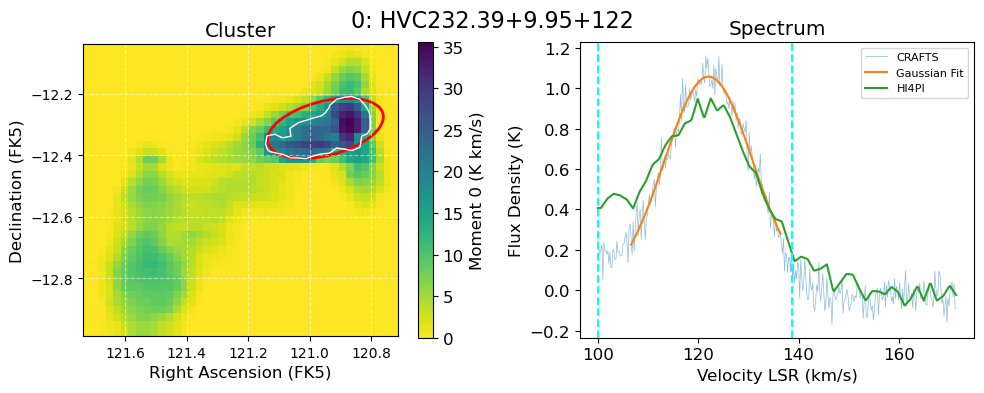

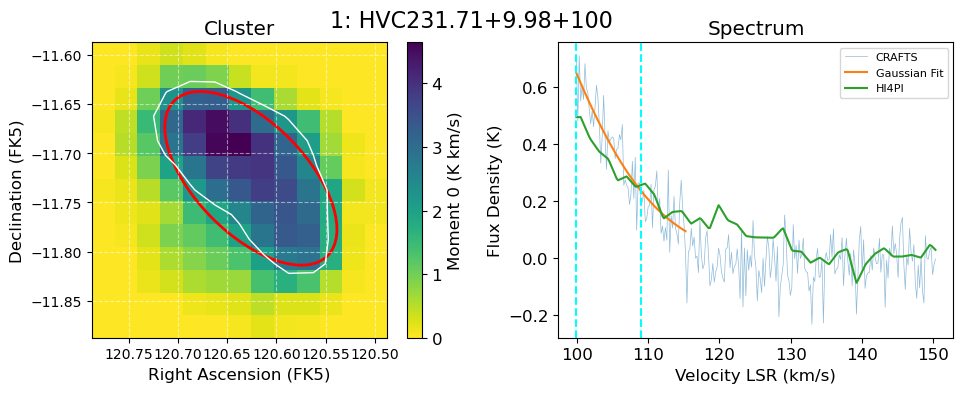

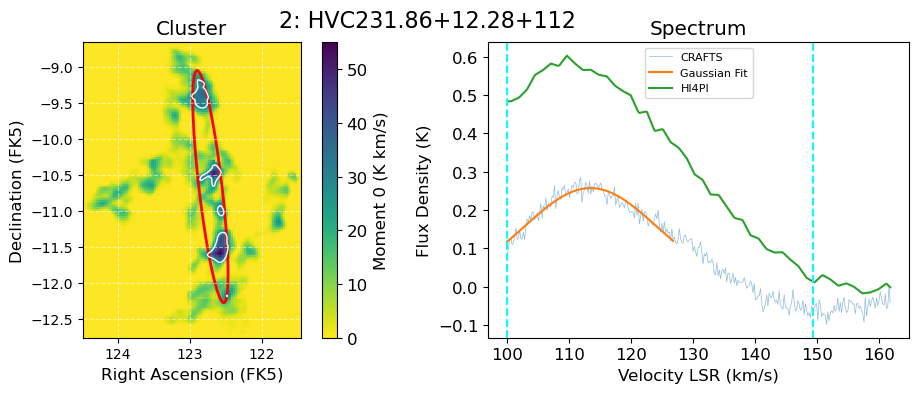

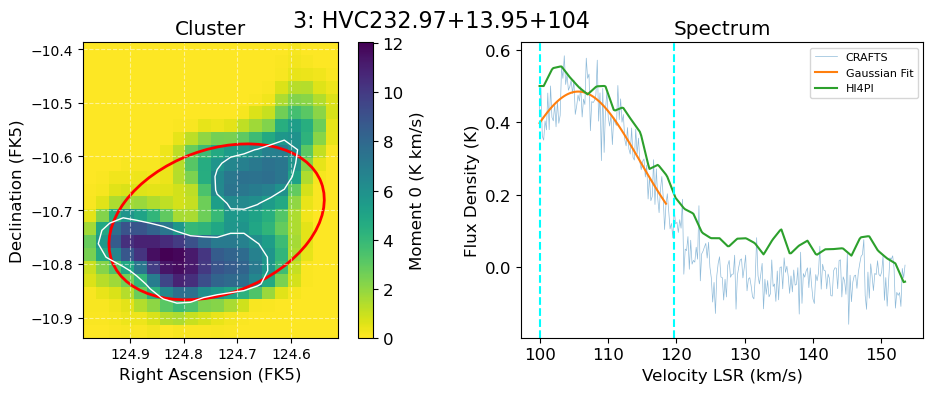

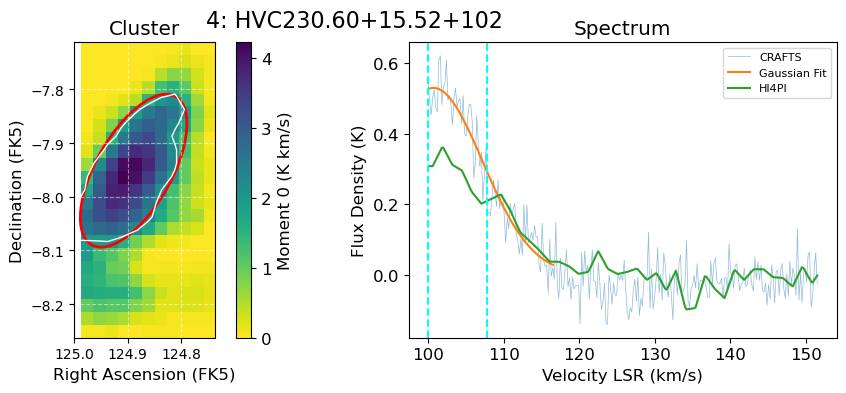

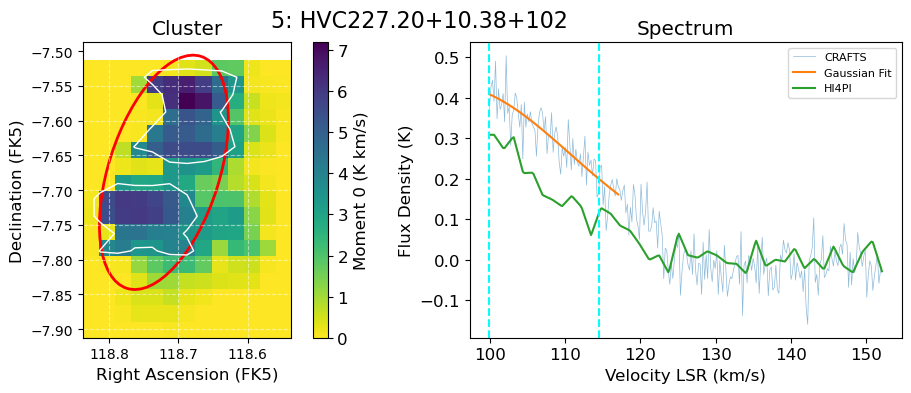

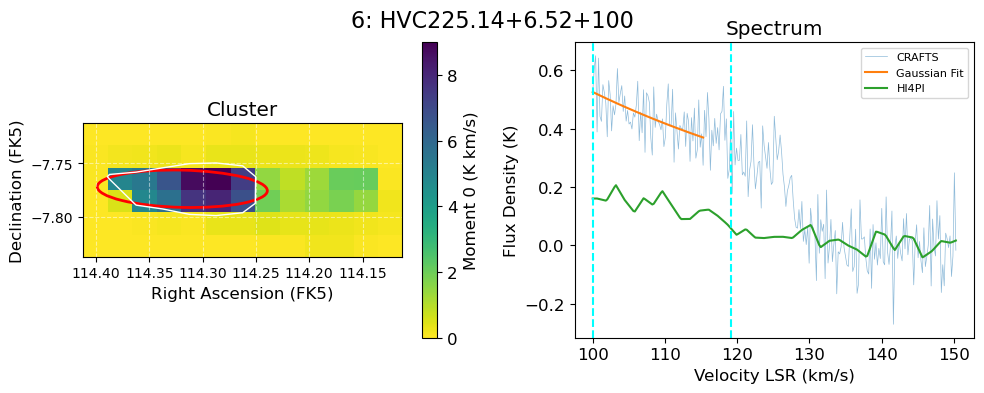

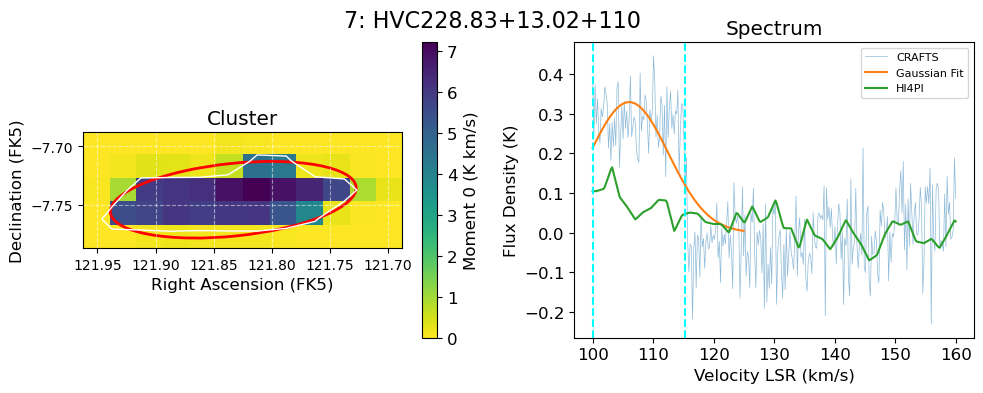

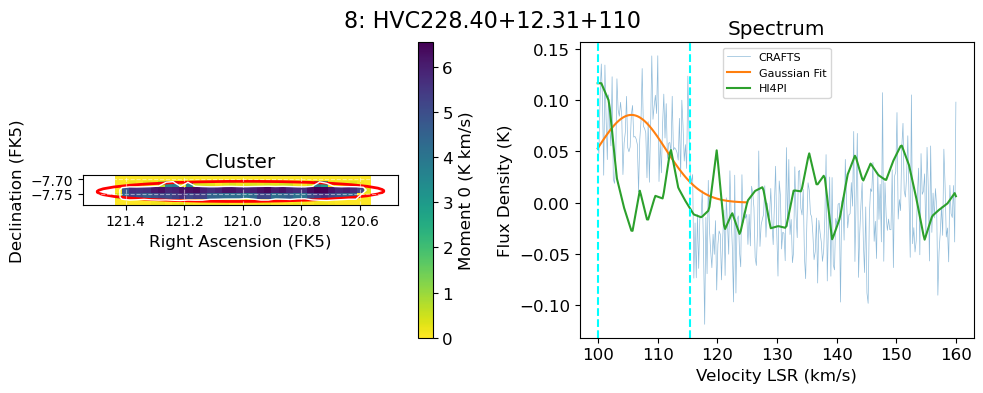

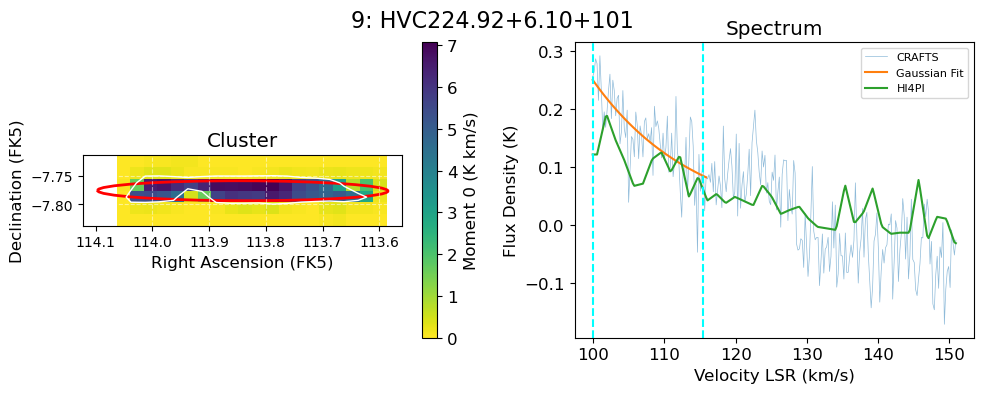

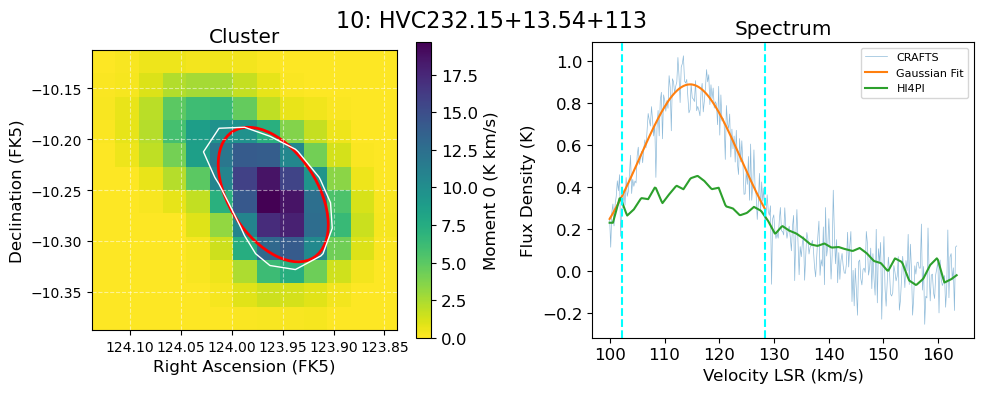

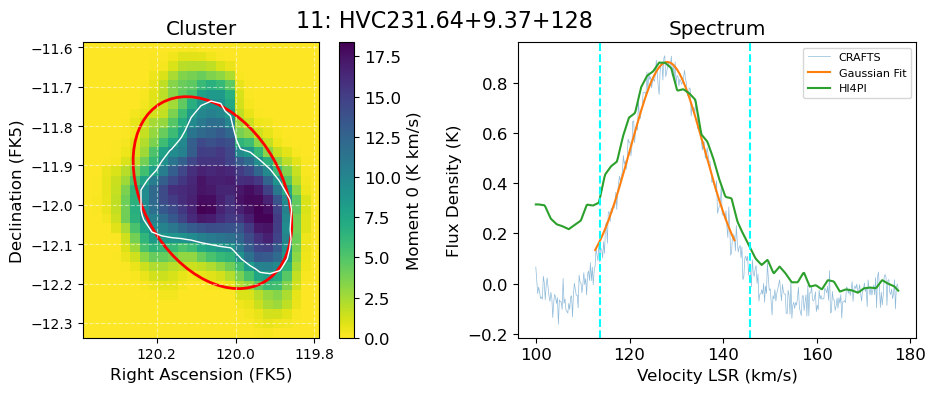

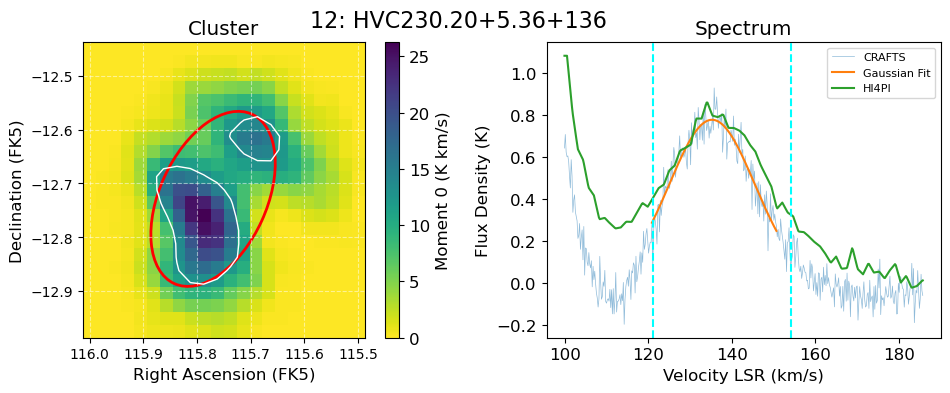

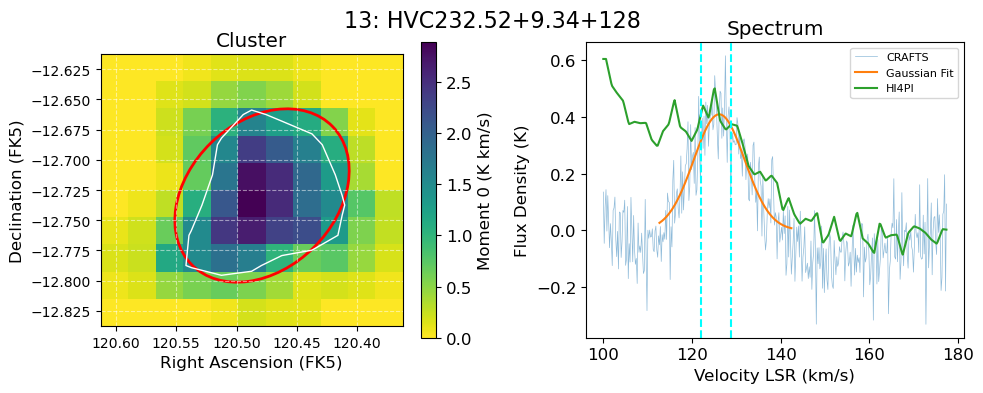

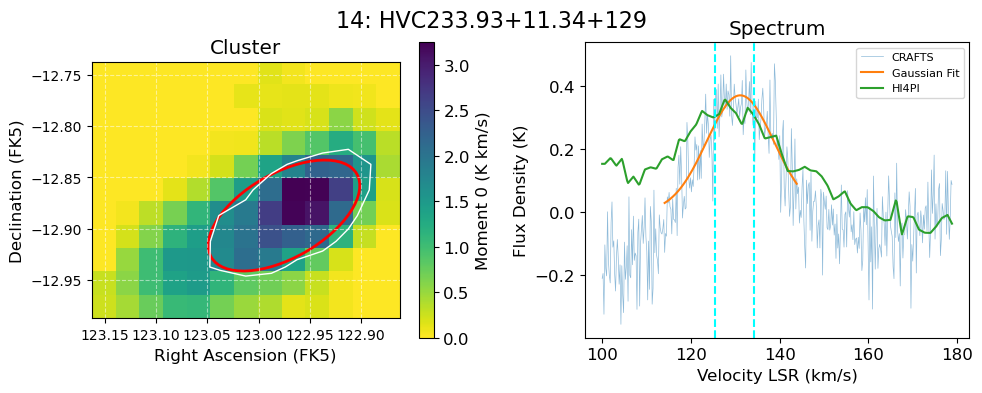

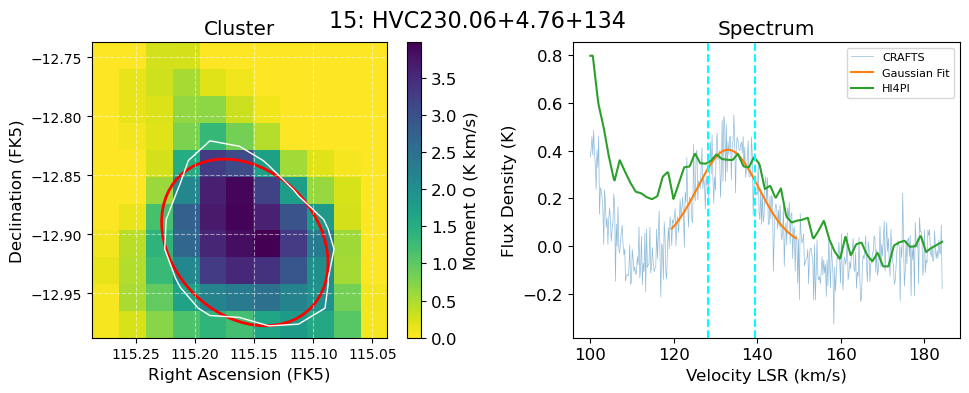

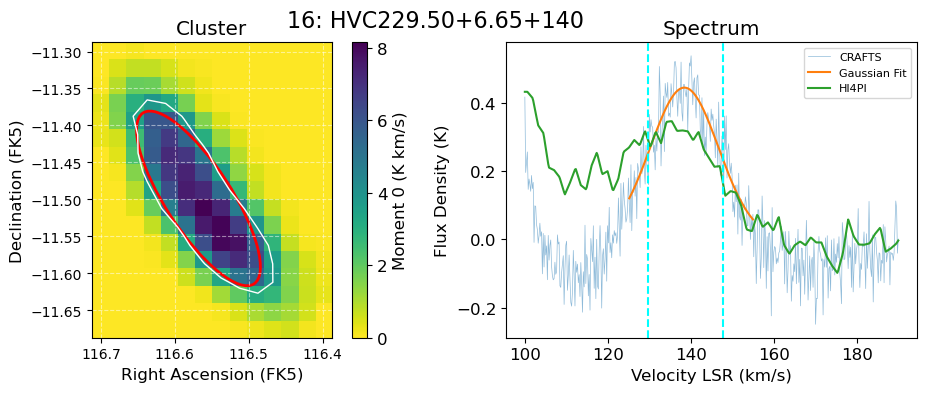

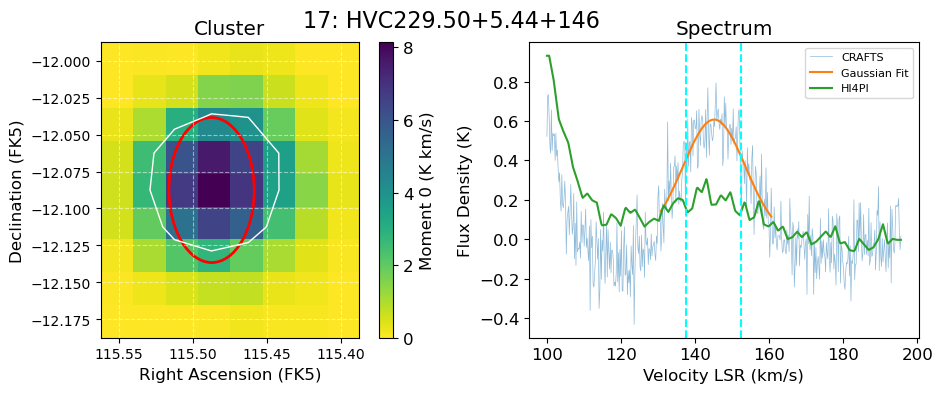

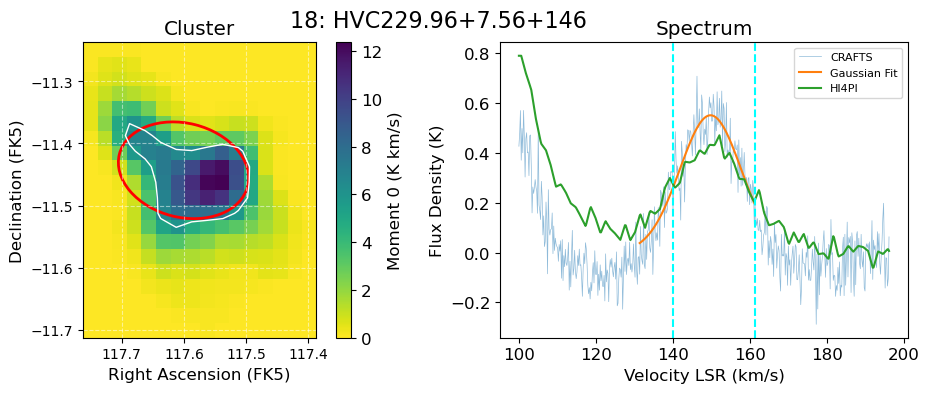

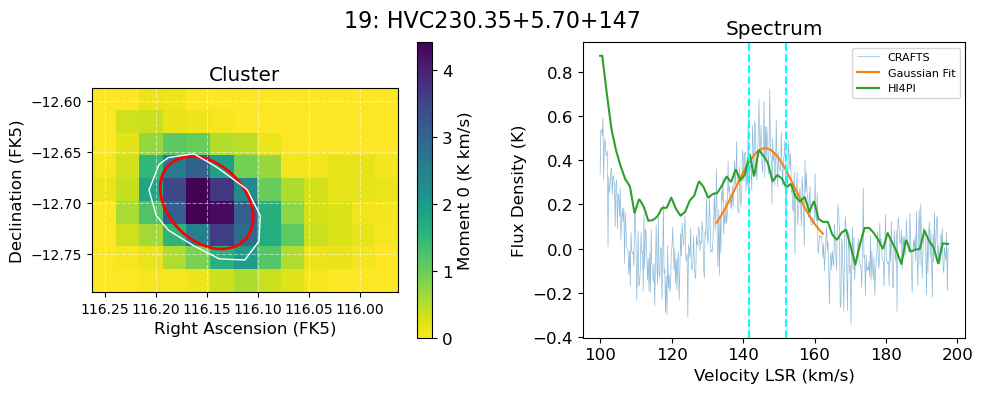

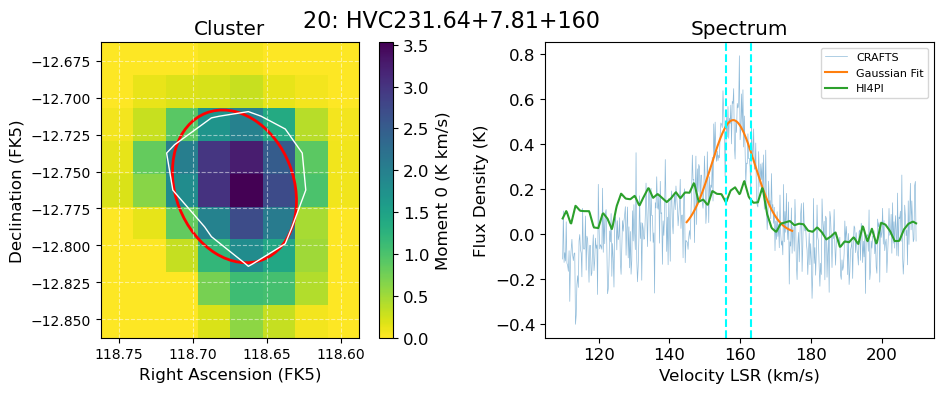

In [27]:
for i in range(len(hvc_candidates)):
    cluster_id = hvc_candidates[i]
    moment_0_crop, extent, xc, yc, a, b, theta, area = cluster_params[i]
    fig, ax = plt.subplots(1, 2, figsize=[10, 4])
    im = ax[0].imshow(
        moment_0_crop,
        extent=extent,
        origin="lower",
        cmap="viridis_r",
        interpolation="none",
    )
    cs = ax[0].contour(
        moment_0_crop,
        levels=[0.5 * np.max(moment_0_crop)],
        extent=extent,
        colors="white",
        linewidths=1,
        linestyles="solid",
    )
    ellipse = Ellipse(
        (xc, yc),
        width=2 * a,
        height=2 * b,
        angle=90 - theta,
        edgecolor="red",
        facecolor="none",
        lw=2,
    )
    ax[0].add_patch(ellipse)
    ax[0].set_xlabel("Right Ascension (FK5)")
    ax[0].tick_params(axis='both', which='both', labelsize=10)
    ax[0].set_ylabel("Declination (FK5)")
    ax[0].set_title(f"Cluster")
    ax[0].grid(color="white", ls="--", alpha=0.5)

    ax[1].plot(crafts_velocity_axis_list[i], crafts_spectra[i], lw=0.5, alpha=0.5, label="CRAFTS")
    ax[1].plot(v_fit_list[i], y_model_list[i], lw=1.5, label="Gaussian Fit")
    ax[1].plot(hi4pi_velocity_axis_list[i], hi4pi_spectra[i], lw=1.5, label="HI4PI")

    ax[1].axvline(VMIN[i], color="cyan", linestyle="--")  # plot the minimum velocity
    ax[1].axvline(VMAX[i], color="cyan", linestyle="--")  # plot the maximum velocity
    ax[1].set_xlabel("Velocity LSR (km/s)")
    ax[1].set_ylabel("Flux Density (K)")
    ax[1].set_title(f"Spectrum")
    ax[1].legend(fontsize=8)

    fig.colorbar(im, ax=ax[0], label="Moment 0 (K km/s)")
    fig.tight_layout()
    fig.suptitle(f"{i}: {ID[i]}", fontsize=16)
    fig.savefig(f"./Figures/{ID[i]}.png", dpi=300)
    plt.show()

# 最后生成HVC源表

In [28]:
# HVC catalog DataFrame
# ID, RA, DEC, GLON, GLAT, VLSR, VGSR, SIZEa, SIZEb, FWHM, SNR, TPKB, N_HI
CATALOG = pd.DataFrame(
    columns=[
        "ID",
        "RA",
        "DEC",
        "GLON",
        "GLAT",
        "VLSR",
        "VDEV",
        "VGSR",
        "SIZEa",
        "SIZEb",
        "SNR",
        "FWHM",
        "TPKB",
        "N_HI",
    ]
)

for i in trange(len(hvc_candidates)):
    cluster_id = hvc_candidates[i]
    # HVC ID
    hvc_id = ID[i]
    # ellipse parameters
    xc, yc, a, b, theta = ellipse_params[i]
    a_arcmin = 2 * a * 60  # major axis in arcmin
    b_arcmin = 2 * b * 60  # minor axis in arcmin
    # coordinates
    c_eq = SkyCoord(xc, yc, frame="fk5", unit="deg")
    c_gal = c_eq.galactic
    ra = c_eq.ra.value
    dec = c_eq.dec.value
    glon = c_gal.l.value
    glat = c_gal.b.value
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    vyx = index[labels == cluster_id]
    bool_array = np.zeros(data.shape, dtype=np.bool_)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array * data
    # peak brightness temperature
    tpkb = np.max(cluster_data)
    # calculate vlsr and vgsr
    vlsr = VPEAK[i]
    vmodel = calc_v_dev(glon, glat, model="poly")
    vdev = vlsr - vmodel[0]
    vgsr = vlsr + 220 * np.sin(np.deg2rad(glon)) * np.cos(np.deg2rad(glat))
    # HI column density
    # MNRAS 432, 3074–3079 (2013)
    n_hi = np.max(moment_0_cube[cluster_id]) * 1.823 / 100  # 1e20 cm^-2
    # SNR and FWHM
    snr = SNR[i]
    fwhm = FWHM[i]
    # fill the catalog
    CATALOG.loc[i] = {
        "ID": hvc_id,
        "RA": ra,
        "DEC": dec,
        "GLON": glon,
        "GLAT": glat,
        "VLSR": vlsr,
        "VDEV": vdev,
        "VGSR": vgsr,
        "SIZEa": a_arcmin,
        "SIZEb": b_arcmin,
        "SNR": snr,
        "FWHM": fwhm,
        "TPKB": tpkb,
        "N_HI": n_hi,
    }

  0%|          | 0/21 [00:00<?, ?it/s]

In [29]:
# CATALOG = CATALOG.sort_values(by=CATALOG.columns[0])
CATALOG

,ID,RA,DEC,GLON,GLAT,VLSR,VDEV,VGSR,SIZEa,SIZEb,SNR,FWHM,TPKB,N_HI
0,HVC232.39+9.95+122,120.949094,-12.311932,232.389734,9.948224,122.057259,29.102406,-49.601987,23.161037,10.576006,12.360853,9.728323,1.629414,0.647826
1,HVC231.71+9.98+100,120.625910,-11.725611,231.714021,9.975918,80.432635,-11.663410,-89.640655,13.280370,6.761362,6.660280,3.913466,0.882158,0.084717
2,HVC231.86+12.28+112,122.717690,-10.664911,231.857970,12.281475,113.416583,21.865846,-55.649690,194.581989,19.221865,21.018608,11.118705,2.764312,1.002062
3,HVC232.97+13.95+104,124.738542,-10.721754,232.969114,13.947451,105.631112,13.330861,-64.819284,24.969459,16.078577,7.794088,7.918039,1.030782,0.219498
4,HVC230.60+15.52+102,124.889033,-7.951492,230.604066,15.517524,100.651303,11.944627,-63.162856,19.045263,8.432640,5.685553,3.669980,0.754386,0.077035
5,HVC227.20+10.38+102,118.720887,-7.674414,227.196129,10.379740,94.816064,8.841367,-63.952964,21.031841,9.569426,5.357509,6.206669,0.711384,0.131021
6,HVC225.14+6.52+100,114.319159,-7.773803,225.142822,6.518194,100.368454,16.465747,-54.574241,9.580949,2.099424,5.288680,7.479446,0.702362,0.163894
7,HVC228.83+13.02+110,121.833079,-7.745863,228.828050,13.018550,106.007421,18.637404,-55.338339,12.758963,3.748025,5.354310,7.950028,0.710965,0.131312
8,HVC228.40+12.31+110,121.007530,-7.742136,228.403667,12.313049,105.619160,18.576967,-55.121207,58.812604,4.126019,5.174677,9.167428,0.687418,0.119159
9,HVC224.92+6.10+101,113.840825,-7.776263,224.917017,6.100762,100.972305,17.331918,-53.485965,30.696995,2.109552,5.801797,6.926465,0.769624,0.128969


In [40]:
false_candidates = [6,7,8,9]  # indices of false candidates
false_candidates_id = [ID[i] for i in false_candidates]
print(false_candidates_id)

CATALOG_NEW = CATALOG[~CATALOG[CATALOG.columns[0]].isin(false_candidates_id)]
ID_NEW = CATALOG_NEW['ID'].values

['HVC225.14+6.52+100', 'HVC228.83+13.02+110', 'HVC228.40+12.31+110', 'HVC224.92+6.10+101']


In [41]:
# save 2D morphology and spectra from CRAFTS and HI4PI to text file for each HVC candidate
# both true and false candidates
for i in range(len(hvc_candidates)):
    id = ID[i]
    np.savetxt(f'./crafts_spectrum/{id}.txt', crafts_spectra[i], fmt='%.6f')
    np.savetxt(f'./hi4pi_spectrum/{id}.txt', hi4pi_spectra[i], fmt='%.6f')
    np.savetxt(f'./2D_morph/{id}.txt', cluster_params[i][0], fmt='%.6f')

In [42]:
CATALOG_NEW.round(2)

,ID,RA,DEC,GLON,GLAT,VLSR,VDEV,VGSR,SIZEa,SIZEb,SNR,FWHM,TPKB,N_HI
0,HVC232.39+9.95+122,120.95,-12.31,232.39,9.95,122.06,29.10,-49.60,23.16,10.58,12.36,9.73,1.63,0.65
1,HVC231.71+9.98+100,120.63,-11.73,231.71,9.98,80.43,-11.66,-89.64,13.28,6.76,6.66,3.91,0.88,0.08
2,HVC231.86+12.28+112,122.72,-10.66,231.86,12.28,113.42,21.87,-55.65,194.58,19.22,21.02,11.12,2.76,1.00
3,HVC232.97+13.95+104,124.74,-10.72,232.97,13.95,105.63,13.33,-64.82,24.97,16.08,7.79,7.92,1.03,0.22
4,HVC230.60+15.52+102,124.89,-7.95,230.60,15.52,100.65,11.94,-63.16,19.05,8.43,5.69,3.67,0.75,0.08
5,HVC227.20+10.38+102,118.72,-7.67,227.20,10.38,94.82,8.84,-63.95,21.03,9.57,5.36,6.21,0.71,0.13
10,HVC232.15+13.54+113,123.96,-10.25,232.15,13.54,114.68,23.23,-54.21,8.83,5.19,9.64,10.45,1.27,0.36
11,HVC231.64+9.37+128,120.06,-11.97,231.64,9.37,128.08,35.91,-42.12,31.44,21.23,10.67,10.11,1.41,0.33
12,HVC230.20+5.36+136,115.77,-12.73,230.20,5.36,135.29,44.16,-32.99,20.82,11.93,11.61,11.19,1.53,0.48
13,HVC232.52+9.34+128,120.48,-12.73,232.52,9.34,126.14,32.86,-46.12,9.80,7.29,6.17,3.64,0.82,0.05


In [43]:
hvc_candidates_filter = np.ones_like(hvc_candidates, dtype=bool)
hvc_candidates_filter[false_candidates] = False

hvc_candidates_filtered = hvc_candidates[hvc_candidates_filter]
ellipse_params_filtered = ellipse_params[hvc_candidates_filter]

In [44]:
vyx_clusters = np.empty((0, 3))
for cluster_id in hvc_candidates_filtered:
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    vyx = index[labels == cluster_id]
    vyx_clusters = np.vstack((vyx_clusters, vyx))
vyx_clusters = vyx_clusters.astype(int)

bool_array = np.zeros(data.shape, dtype=np.bool_)
# mark all points in the clusters (labels == cluster_id) as True
bool_array[vyx_clusters[:, 0], vyx_clusters[:, 1], vyx_clusters[:, 2]] = True

# all HVC candidates cube
# if replace `bool_array` with `mask`, the data before DBSCAN will be displayed
hvc_candidates_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)

# elliptical apertures for all HVC candidates
aper = [
    SkyEllipticalAperture(
        SkyCoord(ra=xc * u.deg, dec=yc * u.deg),
        a * u.deg,
        b * u.deg,
        theta=theta * u.deg,
    )
    for xc, yc, a, b, theta in ellipse_params_filtered
]

In [45]:
moment_0_final = hvc_candidates_cube.moment(order=0)
moment_0_final.write(output_file[0], overwrite=True)

moment_1_final = hvc_candidates_cube.moment(order=1)
moment_1_final.write(output_file[1], overwrite=True)

moment_2_final = hvc_candidates_cube.linewidth_fwhm()
moment_2_final.write(output_file[2], overwrite=True)

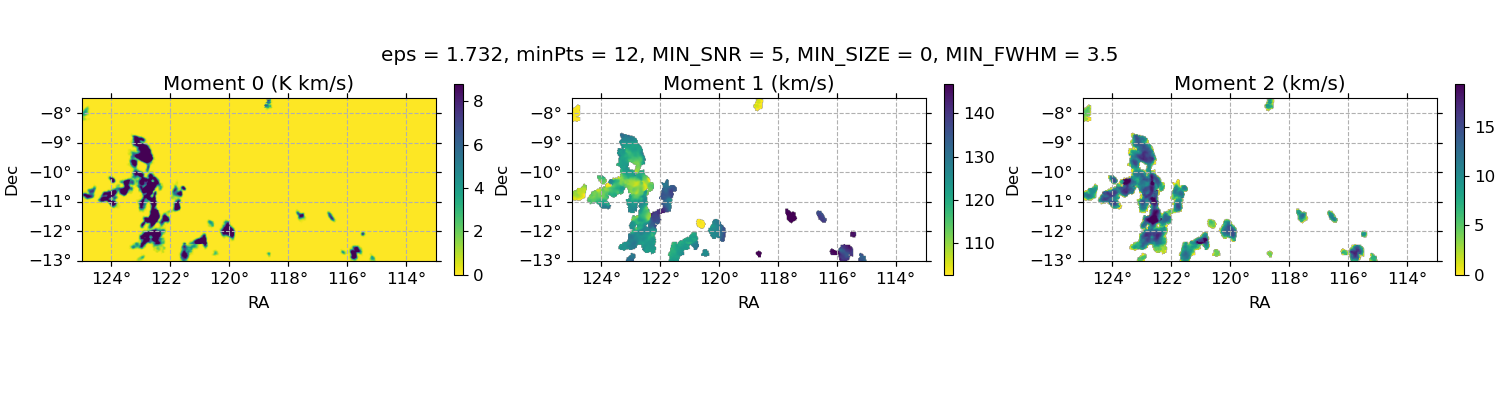

(<Figure size 1500x400 with 6 Axes>,
 array([<WCSAxes: title={'center': 'Moment 0 (K km/s)'}>,
        <WCSAxes: title={'center': 'Moment 1 (km/s)'}>,
        <WCSAxes: title={'center': 'Moment 2 (km/s)'}>], dtype=object))

In [46]:
def plot_moments(
    moments,
    titles,
    wcs,
    aper,
    idx,
    eps,
    minPts,
    MIN_SNR,
    MIN_SIZE,
    MIN_FWHM,
    figsize=(15, 4),
):
    n = len(moments)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=figsize,
        sharex=True,
        sharey=True,
        layout="compressed",
        subplot_kw={"projection": wcs.celestial},
    )

    # Ensure axes is a 1-D iterable even when n == 1 (plt.subplots returns a single Axes)
    axes = np.atleast_1d(axes)

    annotate_kwargs = {
        "color": "white",
        "fontsize": 9,
        "ha": "center",
        "va": "center",
        "bbox": dict(facecolor="black", alpha=0.6, pad=1, edgecolor="none"),
        "zorder": 1000,
    }

    for ax, moment, title in zip(axes, moments, titles):
        # support astropy Quantity-like objects with .value, or plain ndarrays
        data = getattr(moment, "value", moment)

        norm = None if np.all(np.isnan(data)) else simple_norm(data, percent=95)
        im = ax.imshow(data, norm=norm, cmap="viridis_r", origin="lower")

        # plot apertures
        for aper_i, text in zip(aper, idx):
            aper_to_pixels = aper_i.to_pixel(wcs.celestial)
            aper_to_pixels.plot(ax=ax, color="red", lw=1)

            pos = aper_to_pixels.positions
            ax.annotate(str(text), xy=(pos[0], pos[1]), xycoords="data", **annotate_kwargs)

        ax.grid(linestyle="--")
        ax.set_title(title)

        lon = ax.coords[0]
        lat = ax.coords[1]
        lon.set_major_formatter("dd")
        lat.set_major_formatter("dd")
        lon.set_axislabel("RA")
        lat.set_axislabel("Dec")

        # Use fig.colorbar (not plt.colorbar) to avoid layout engine conflicts
        fig.colorbar(im, ax=ax)

    fig.suptitle(
        f"eps = {np.round(eps, 3)}, minPts = {minPts}, MIN_SNR = {MIN_SNR}, "
        f"MIN_SIZE = {MIN_SIZE}, MIN_FWHM = {MIN_FWHM}"
    )

    plt.show()

    return fig, axes


# Example usage:
plot_moments(
    moments=[moment_0_final, moment_1_final, moment_2_final],
    titles=["Moment 0 (K km/s)", "Moment 1 (km/s)", "Moment 2 (km/s)"],
    wcs=wcs,
    aper=aper,
    idx=[],
    eps=eps,
    minPts=minPts,
    MIN_SNR=MIN_SNR,
    MIN_SIZE=MIN_SIZE,
    MIN_FWHM=MIN_FWHM,
    figsize=(15, 4)
)

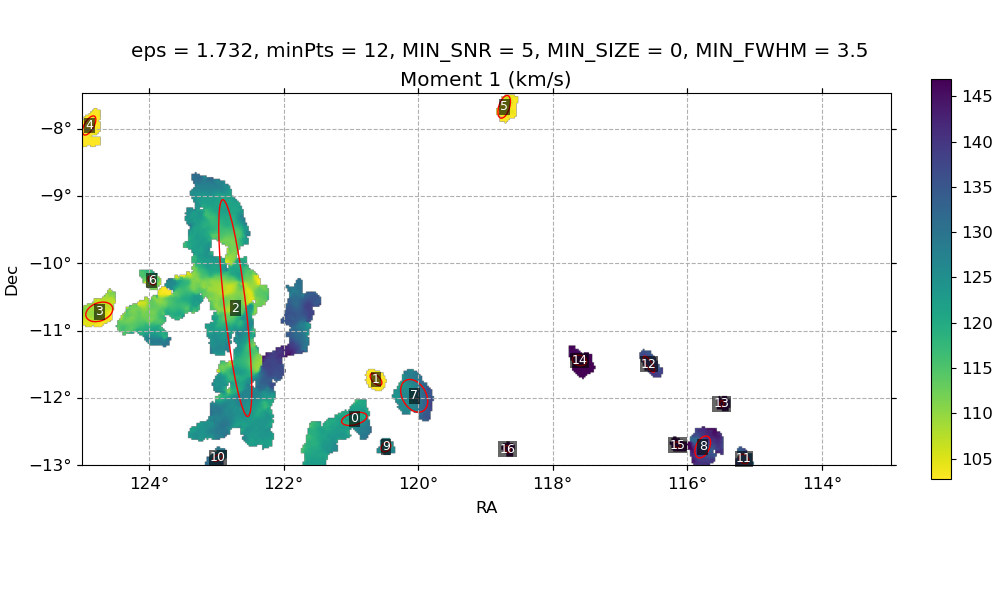

(<Figure size 1000x600 with 2 Axes>,
 array([<WCSAxes: title={'center': 'Moment 1 (km/s)'}>], dtype=object))

In [47]:
plot_moments(
    moments=[moment_1_final],
    titles=["Moment 1 (km/s)"],
    wcs=wcs,
    aper=aper,
    idx=[i for i in range(len(hvc_candidates_filtered))],
    eps=eps,
    minPts=minPts,
    MIN_SNR=MIN_SNR,
    MIN_SIZE=MIN_SIZE,
    MIN_FWHM=MIN_FWHM,
    figsize=(10, 6)
)

# 记录表

eps = 1, sqrt(2), sqrt(3)

min_samples = 2, 4, 6,  
              6, 9, 12, 15, 18,
              6, 9, 12, 15, 18, 19

**记录每一个(eps, min_samples)参数组下，表现最好的SNR/spatial_pixels/FWHM**

N为HVC candidate数目，F为其中的假信号数目，T为其中的真信号数目

| eps | minPts |     | SNR | FWHM(km/s) |     | N   | T   | F   |
| --- | ------ | --- | --- | ---------- | --- | --- | --- | --- |
| 3   | 19     |     | 6.5 | 6          |     | 16  | 16  | 0   |
| 3   | 18     |     | 5   | 4          |     | 15  | 15  | 0   |
| 3   | 15     |     | 5   | 3.5        |     | 17  | 14  | 3   |
| 3   | 12     |     | 5   | 3.5        |     | 21  | 17  | 4   |
| 3   | 9      |     | 4.5 | 3.5        |     | 20  | 16  | 4   |
| 3   | 6      |     | 5   | 3.5        |     | 20  | 16  | 4   |
|     |        |     |     |            |     |     |     |     |
| 2   | 18     |     | 5   | 4          |     | 14  | 14  | 0   |
| 2   | 15     |     | 5   | 3.5        |     | 17  | 14  | 3   |
| 2   | 12     |     | 5   | 3.5        |     | 21  | 17  | 4   |
| 2   | 9      |     | 4.5 | 4          |     | 20  | 16  | 4   |
| 2   | 6      |     | 5   | 3.5        |     | 20  | 16  | 4   |
|     |        |     |     |            |     |     |     |     |
| 1   | 6      |     | 5   | 3.5        |     | 19  | 15  | 4   |
| 1   | 4      |     | 4.5 | 3.5        |     | 19  | 16  | 3   |
| 1   | 2      |     | 5   | 3.5        |     | 19  | 16  | 3   |


```
all_false_hvc_candidates = [
    # RA = 0, sign = +
    'HVC209.05-24.89+89', 'HVC205.30-31.02+84', 'HVC208.94-24.49+86',
    'HVC202.90-34.43+86', 'HVC201.79-35.94+89', 'HVC203.59-33.19+85',
    'HVC208.80-24.16+90', 'HVC207.81-25.39+89', 'HVC204.37-31.28+85',
    'HVC201.30-35.94+92', 'HVC208.50-23.92+86', 'HVC197.97-40.40+89',
    'HVC206.88-27.51+101', 'HVC200.30-37.65+89', 'HVC200.18-36.69+102'
    'HVC199.15-39.16+88', 'HVC203.58-32.88+88', 'HVC202.81-32.05+201',
    'HVC200.20-36.66+271'
    
    # RA = 1, sign = +
    'HVC208.88-19.07+139',
    
    # RA = 2, sign = +
    'HVC222.40+12.31+253', 'HVC218.79+5.44+258', 'HVC218.92+5.70+268'
    
    # RA = 3, sign = +
    'HVC240.84+21.50+296'

    # RA = 0, sign = -
    'HVC206.06-28.44-251', 'HVC206.35-27.95-254', 'HVC202.82-24.68-247',
    'HVC195.02-36.10-245', 'HVC201.60-36.08-179', 'HVC199.28-31.78-57',
    'HVC199.50-31.25-62', 'HVC197.20-34.63-57', 'HVC197.79-33.79-57',
    'HVC196.18-36.17-75', 'HVC196.58-35.57-89', 'HVC199.14-39.20-82',
    'HVC202.58-26.54-80', 'HVC199.10-31.75-60', 'HVC197.55-34.15-57'
    
    # RA = 1, sign = -
    'HVC206.07-18.98-255', 'HVC211.76-5.86-113', 'HVC213.97-5.54-103',
    'HVC211.97-11.03-59', 'HVC208.90-15.40-80'
    
    # RA = 2, sign = -
    'HVC215.71-0.46-250', 'HVC217.51+3.10-249', 'HVC219.10+6.16-250',
    'HVC221.51+5.98-80'
    
    # RA = 3, sign = -
    'HVC224.97+16.83-250', 'HVC234.71+14.63-212', 'HVC233.48+21.12-85',
    'HVC235.91+24.73-69', 'HVC228.50+28.98-71'
]
```